In [1]:
import pandas as pd
import numpy as np
import plotnine as p9
from plotnine import * # imports everything from plotnine for use
from mizani.formatters import comma_format
import calendar
import time
from plotnine.scales import scale_x_datetime, scale_y_datetime
import matplotlib.pyplot as plt

In [2]:
# import Excel sheet
data1 = pd.read_excel("SDOH_2020_COUNTY_Cleaned.xlsx", sheet_name="Data")

In [3]:
# visualize head to understand column names
data1.head()

,YEAR,COUNTYFIPS,STATEFIPS,STATE,COUNTY,REGION,AHRF_USDA_RUCC_2013,AHRF_HPSA_DENTIST,AHRF_HPSA_MENTAL,AHRF_HPSA_PRIM,...,POS_HOSP_PSYCH_RATE,POS_TOT_HOSP_AMBULANCE,POS_HOSP_AMBULANCE_RATE,POS_TOT_HOSP_CHEMO,POS_HOSP_CHEMO_RATE,POS_TOT_HOSP_ED,POS_HOSP_ED_RATE,POS_PCT_HOSP_FOR_PROFIT,POS_PCT_HOSP_NON_PROFIT,POS_PCT_HOSP_GOV
0,2020,1001,1,Alabama,Autauga County,South,2.0,2.0,2.0,2.0,...,0.0,0.0,0.00,0.0,0.0,1.0,0.02,52.63,36.84,10.53
1,2020,1003,1,Alabama,Baldwin County,South,3.0,2.0,1.0,2.0,...,0.0,0.0,0.00,1.0,0.0,4.0,0.02,63.49,36.51,0.00
2,2020,1005,1,Alabama,Barbour County,South,6.0,2.0,2.0,1.0,...,0.0,0.0,0.00,0.0,0.0,1.0,0.04,68.75,25.00,6.25
3,2020,1007,1,Alabama,Bibb County,South,1.0,2.0,2.0,1.0,...,0.0,1.0,0.04,0.0,0.0,1.0,0.04,46.15,30.77,23.08
4,2020,1009,1,Alabama,Blount County,South,1.0,2.0,2.0,1.0,...,0.0,0.0,0.00,0.0,0.0,1.0,0.02,60.00,40.00,0.00


In [4]:
# drop every state that is not Alabama
data1 = data1[data1['STATE']=='Alabama']

In [5]:
# Winston Co is the last county of Alabama
data1.tail()

,YEAR,COUNTYFIPS,STATEFIPS,STATE,COUNTY,REGION,AHRF_USDA_RUCC_2013,AHRF_HPSA_DENTIST,AHRF_HPSA_MENTAL,AHRF_HPSA_PRIM,...,POS_HOSP_PSYCH_RATE,POS_TOT_HOSP_AMBULANCE,POS_HOSP_AMBULANCE_RATE,POS_TOT_HOSP_CHEMO,POS_HOSP_CHEMO_RATE,POS_TOT_HOSP_ED,POS_HOSP_ED_RATE,POS_PCT_HOSP_FOR_PROFIT,POS_PCT_HOSP_NON_PROFIT,POS_PCT_HOSP_GOV
62,2020,1125,1,Alabama,Tuscaloosa County,South,3.0,2.0,2.0,2.0,...,0.02,0.0,0.0,1.0,0.00,3.0,0.01,65.63,23.44,10.94
63,2020,1127,1,Alabama,Walker County,South,1.0,2.0,1.0,2.0,...,0.02,0.0,0.0,1.0,0.02,1.0,0.02,79.49,20.51,0.00
64,2020,1129,1,Alabama,Washington County,South,8.0,2.0,2.0,1.0,...,0.00,0.0,0.0,0.0,0.00,1.0,0.06,22.22,33.33,44.44
65,2020,1131,1,Alabama,Wilcox County,South,9.0,2.0,1.0,1.0,...,0.00,0.0,0.0,0.0,0.00,1.0,0.09,53.85,46.15,0.00
66,2020,1133,1,Alabama,Winston County,South,6.0,2.0,1.0,1.0,...,0.00,0.0,0.0,0.0,0.00,1.0,0.04,91.67,8.33,0.00


In [6]:
# drop unneeded columns, visualize again

data1 = data1.drop(columns=['COUNTYFIPS', 'STATEFIPS', 'REGION'])
data1.head()

,YEAR,STATE,COUNTY,AHRF_USDA_RUCC_2013,AHRF_HPSA_DENTIST,AHRF_HPSA_MENTAL,AHRF_HPSA_PRIM,AHRF_TOT_ADV_NURSES,AHRF_ADV_NURSES_RATE,AHRF_TOT_CLIN_NURSE_SPEC,...,POS_HOSP_PSYCH_RATE,POS_TOT_HOSP_AMBULANCE,POS_HOSP_AMBULANCE_RATE,POS_TOT_HOSP_CHEMO,POS_HOSP_CHEMO_RATE,POS_TOT_HOSP_ED,POS_HOSP_ED_RATE,POS_PCT_HOSP_FOR_PROFIT,POS_PCT_HOSP_NON_PROFIT,POS_PCT_HOSP_GOV
0,2020,Alabama,Autauga County,2.0,2.0,2.0,2.0,30.0,0.53,1.0,...,0.0,0.0,0.00,0.0,0.0,1.0,0.02,52.63,36.84,10.53
1,2020,Alabama,Baldwin County,3.0,2.0,1.0,2.0,187.0,0.82,4.0,...,0.0,0.0,0.00,1.0,0.0,4.0,0.02,63.49,36.51,0.00
2,2020,Alabama,Barbour County,6.0,2.0,2.0,1.0,15.0,0.61,0.0,...,0.0,0.0,0.00,0.0,0.0,1.0,0.04,68.75,25.00,6.25
3,2020,Alabama,Bibb County,1.0,2.0,2.0,1.0,37.0,1.67,0.0,...,0.0,1.0,0.04,0.0,0.0,1.0,0.04,46.15,30.77,23.08
4,2020,Alabama,Blount County,1.0,2.0,2.0,1.0,18.0,0.31,0.0,...,0.0,0.0,0.00,0.0,0.0,1.0,0.02,60.00,40.00,0.00


In [8]:
# Count how many missing values exist before filling
missing_count = data1.isna().sum().sum()

# get location of each missing value
missing_locations = data1.isna()
rows, cols = np.where(missing_locations)
for r, c in zip(rows, cols):
    print(f"Missing value at row {r}, column '{data1.columns[c]}'")

# Fill all missing values with "NA"
data1 = data1.fillna("NA")

print(f"Filled {missing_count} missing values with 'NA'.")


Missing value at row 42, column 'CHR_MENTAL_PROV_RATE'
Filled 1 missing values with 'NA'.


In [ ]:
# see how many counties are each count of the rural categories 
# 1-3 is metro areas of 250,000+ people
# 3-9 are seperated in groups of 20,000 or more, adjacent to a metro or not; 2,500-19,999 adjacent or not to a metro area; less than 2,500 adjacent or not to a metro area
# 9 is the most rural with less than 2,500 people and not adjacent to a rural area
# there are no counties with a 5 designation

# for Alabama, the most common type of county is 6 - 2,500-19,999 and adjacent to a metro area. Followed by 3 - fewer than 250,000 population

counts = data1["AHRF_USDA_RUCC_2013"].value_counts().sort_index()
print(counts)

# making sure counties are not being double counted or can be given two values
print(counts.sum())
print(f"There are {len(data1)} counties")


AHRF_USDA_RUCC_2013
1.0     7
2.0     8
3.0    14
4.0     6
6.0    16
7.0     5
8.0     8
9.0     3
Name: count, dtype: int64
67
There are 67 counties


In [ ]:
# visualize the rate of urgent care center per 100,000 population column to understand data
# this is the rate of urgent care centers per 100,000 population - should be a percentage

print(data1["HIFLD_UC_RATE"].head())



0    0.02
1    0.03
2    0.00
3    0.00
4    0.00
Name: HIFLD_UC_RATE, dtype: float64


In [17]:
# average rate of urgent care centers per each rural-metro code
# i want to stratify based on rural-metro code and then get the average of the column

avg_urgent_by_code = (
    data1
    .groupby("AHRF_USDA_RUCC_2013", as_index=False)["HIFLD_UC_RATE"]
    .mean()
)

print(avg_urgent_by_code)


   AHRF_USDA_RUCC_2013  HIFLD_UC_RATE
0                  1.0       0.015714
1                  2.0       0.027500
2                  3.0       0.015714
3                  4.0       0.015000
4                  6.0       0.001875
5                  7.0       0.000000
6                  8.0       0.011250
7                  9.0       0.026667


In [18]:
# multiply urgent care rate by 100 bc it is a percent
avg_urgent_by_code["HIFLD_UC_RATE"] = avg_urgent_by_code["HIFLD_UC_RATE"] * 100

print(avg_urgent_by_code)


   AHRF_USDA_RUCC_2013  HIFLD_UC_RATE
0                  1.0       1.571429
1                  2.0       2.750000
2                  3.0       1.571429
3                  4.0       1.500000
4                  6.0       0.187500
5                  7.0       0.000000
6                  8.0       1.125000
7                  9.0       2.666667


In [23]:
import plotly.express as px

fig = px.bar(
    avg_urgent_by_code,
    x="AHRF_USDA_RUCC_2013",
    y="HIFLD_UC_RATE",
    title="Average HIFLD Urgent Care Rate by Rural-Metro Code",
    labels={"AHRF_USDA_RUCC_2013": "Rural-Metro Code", "HIFLD_UC_RATE": "HIFLD UC Rate (%)"},
)
fig.show()


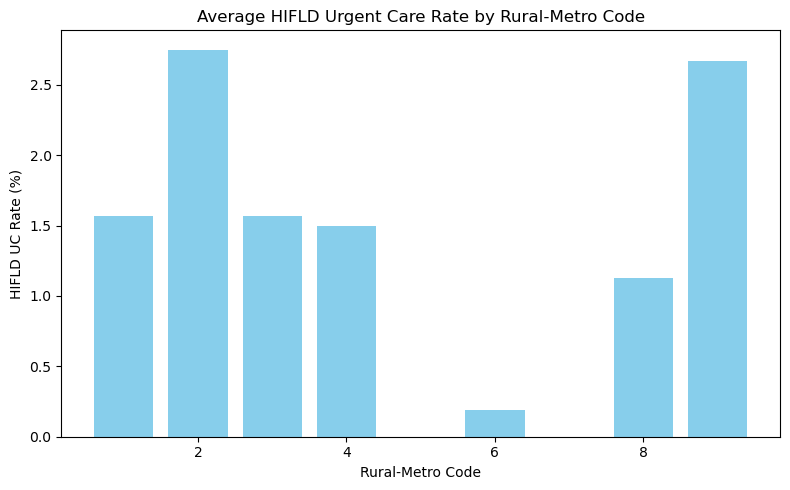

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(avg_urgent_by_code["AHRF_USDA_RUCC_2013"], avg_urgent_by_code["HIFLD_UC_RATE"], color="skyblue")
plt.title("Average HIFLD Urgent Care Rate by Rural-Metro Code")
plt.xlabel("Rural-Metro Code")
plt.ylabel("HIFLD UC Rate (%)")
plt.tight_layout()
plt.show()


<Axes: title={'center': 'Average HIFLD Urgent Care Rate by Rural-Metro Code'}, xlabel='Rural-Metro Code', ylabel='HIFLD UC Rate (%)'>

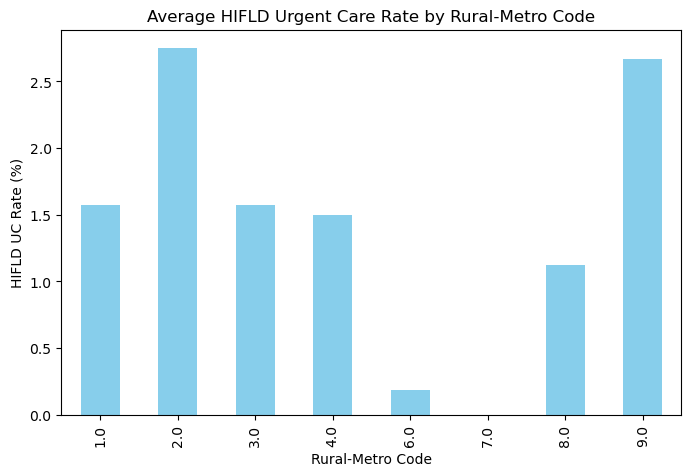

In [21]:
avg_urgent_by_code.plot(
    x="AHRF_USDA_RUCC_2013",
    y="HIFLD_UC_RATE",
    kind="bar",
    legend=False,
    title="Average HIFLD Urgent Care Rate by Rural-Metro Code",
    ylabel="HIFLD UC Rate (%)",
    xlabel="Rural-Metro Code",
    color="skyblue",
    figsize=(8,5)
)


	From AHRF User Guide 2020
    
    CODE				METROPOLITAN COUNTIES (1-3)

	01		Counties in metro areas of 1 million population or more
	02		Counties in metro areas of 250,000 – 1,000,000 population
	03		Counties in metro areas of fewer than 250,000 population
	
						NONMETROPOLITAN COUNTIES (4-9)
						
	04		Urban population of 20,000 or more, adjacent to a metro area
	05		Urban population of 20,000 or more, not adjacent to a metro area
	06		Urban population of 2,500-19,999, adjacent to a metro area
	07		Urban population of 2,500-19,999, not adjacent to a metro area
	08		Completely rural or less than 2,500 urban population, adjacent to a metro area
	09		Completely rural or less than 2,500 urban population, not adjacent to a metro area
